# Gaussian Simulated Raman Spectra: Multi-Molecule Workflow

This notebook reads Gaussian Raman data for multiple molecules, applies scaling, generates stick and broadened spectra, and exports publication-quality plots and processed CSV files.

## 1. Configuration
Set input/output paths and processing parameters.

In [1]:
from pathlib import Path

# ---- User settings ----
INPUT_FOLDER = Path(r"c:/Users/COMPUTER/Downloads/sukesh/LPS/excelsheet")
OUTPUT_ROOT = INPUT_FOLDER / "output"

SCALING_FACTOR = 0.967
FWHM = 12.0  # cm^-1, typically 10-15
X_MIN, X_MAX = 400.0, 1800.0
X_STEP = 1.0

# Optional: provide experimental Raman files (csv/xlsx/xls/txt/log)
# Keys should match molecule names (usually filename stem).
EXPERIMENTAL_FILES = {
    # "Myristic Acid": Path(r"path/to/myristic_experimental.csv"),
}

# Molecules of interest (optional filter). Leave empty list to process all supported files in INPUT_FOLDER.
TARGET_MOLECULES = [
    "L-Glycero-D-Manno-Heptose",
    "3-Deoxy-D-Manno-Octulosonic Acid",
    "Myristic Acid",
    "Phosphoric acid",
    "D-glucosamine",
]

SUPPORTED_EXTENSIONS = {".csv", ".xlsx", ".xls", ".log", ".out", ".txt"}

# Export folders
INDIVIDUAL_PLOTS_DIR = OUTPUT_ROOT / "individual_plots"
COMBINED_PLOTS_DIR = OUTPUT_ROOT / "combined_plots"
PROCESSED_DATA_DIR = OUTPUT_ROOT / "processed_data"

for p in [OUTPUT_ROOT, INDIVIDUAL_PLOTS_DIR, COMBINED_PLOTS_DIR, PROCESSED_DATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Input folder: {INPUT_FOLDER}")
print(f"Output root : {OUTPUT_ROOT}")

Input folder: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet
Output root : c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output


## 2. Imports and Plot Style

In [2]:
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "lines.linewidth": 1.8,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

## 3. Utility Functions
These functions parse Gaussian log files or tabular files, apply scaling, broaden spectra, normalize intensities, and save outputs.

In [3]:
def sanitize_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


def find_matching_column(columns, include_keywords, exclude_keywords=None):
    exclude_keywords = exclude_keywords or []
    for col in columns:
        c = str(col).lower()
        if any(k in c for k in include_keywords) and not any(x in c for x in exclude_keywords):
            return col
    return None


def parse_tabular_file(path: Path):
    ext = path.suffix.lower()
    if ext == ".csv":
        df = pd.read_csv(path)
    elif ext in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    else:
        # Generic text fallback with auto-delimiter detection
        df = pd.read_csv(path, sep=None, engine="python")

    df.columns = [str(c).strip() for c in df.columns]

    freq_col = find_matching_column(
        df.columns,
        include_keywords=["freq", "wavenumber", "cm", "cm-1", "cm^-1"],
    )
    act_col = find_matching_column(
        df.columns,
        include_keywords=["raman", "activity", "activities", "act"],
        exclude_keywords=["frequency", "freq"],
    )

    if freq_col is None or act_col is None:
        numeric_df = df.select_dtypes(include=[np.number])
        if numeric_df.shape[1] < 2:
            # Try coercion if columns were read as strings
            coerced = df.apply(pd.to_numeric, errors="coerce")
            numeric_df = coerced.dropna(axis=1, how="all")
        if numeric_df.shape[1] < 2:
            raise ValueError(f"Could not find at least two numeric columns in {path.name}")
        freq = numeric_df.iloc[:, 0].to_numpy(dtype=float)
        activity = numeric_df.iloc[:, 1].to_numpy(dtype=float)
    else:
        freq = pd.to_numeric(df[freq_col], errors="coerce").to_numpy(dtype=float)
        activity = pd.to_numeric(df[act_col], errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(freq) & np.isfinite(activity) & (freq > 0)
    return freq[mask], activity[mask]


def parse_gaussian_log(path: Path):
    text = path.read_text(errors="ignore")

    freq_lines = re.findall(r"Frequencies\s*--\s*([^\n\r]+)", text, flags=re.IGNORECASE)
    act_lines = re.findall(r"Raman\s+Activ(?:ities)?\s*--\s*([^\n\r]+)", text, flags=re.IGNORECASE)

    freqs = []
    acts = []

    for line in freq_lines:
        freqs.extend([float(x) for x in re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)])

    for line in act_lines:
        acts.extend([float(x) for x in re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)])

    n = min(len(freqs), len(acts))
    if n == 0:
        raise ValueError(f"No Raman frequency/activity pairs found in {path.name}")

    freq = np.array(freqs[:n], dtype=float)
    activity = np.array(acts[:n], dtype=float)

    mask = np.isfinite(freq) & np.isfinite(activity) & (freq > 0)
    return freq[mask], activity[mask]


def read_raman_file(path: Path):
    ext = path.suffix.lower()
    if ext in {".log", ".out"}:
        return parse_gaussian_log(path)
    return parse_tabular_file(path)


def gaussian_broaden(x, frequencies, intensities, fwhm):
    sigma = fwhm / (2.0 * math.sqrt(2.0 * math.log(2.0)))
    y = np.zeros_like(x, dtype=float)

    # Sum Gaussian contributions from all vibrational modes
    for f, a in zip(frequencies, intensities):
        y += a * np.exp(-((x - f) ** 2) / (2.0 * sigma ** 2))

    return y


def normalize(y):
    y = np.asarray(y, dtype=float)
    ymax = np.max(y) if y.size else 0.0
    return y / ymax if ymax > 0 else y


def crop_region(freq, inten, x_min, x_max):
    m = (freq >= x_min) & (freq <= x_max)
    return freq[m], inten[m]

## 4. Discover Input Files

In [4]:
all_files = sorted([p for p in INPUT_FOLDER.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS])

if TARGET_MOLECULES:
    target_set = {m.lower().strip() for m in TARGET_MOLECULES}
    input_files = [p for p in all_files if p.stem.lower().strip() in target_set]
else:
    input_files = all_files

if not input_files:
    raise FileNotFoundError("No supported input files found in INPUT_FOLDER.")

print(f"Found {len(input_files)} input file(s):")
for p in input_files:
    print(f"  - {p.name}")

Found 5 input file(s):
  - 3-Deoxy-D-Manno-Octulosonic Acid.xlsx
  - D-glucosamine.xlsx
  - L-Glycero-D-Manno-Heptose.xlsx
  - Myristic Acid.xlsx
  - Phosphoric acid.xlsx


## 5. Process Files and Save Individual Outputs
For each molecule this cell:
- extracts frequencies and Raman activities
- applies scaling factor
- generates stick and broadened spectra
- crops to 400-1800 cm^-1
- normalizes intensities
- saves processed CSV files and publication-quality PNG/SVG

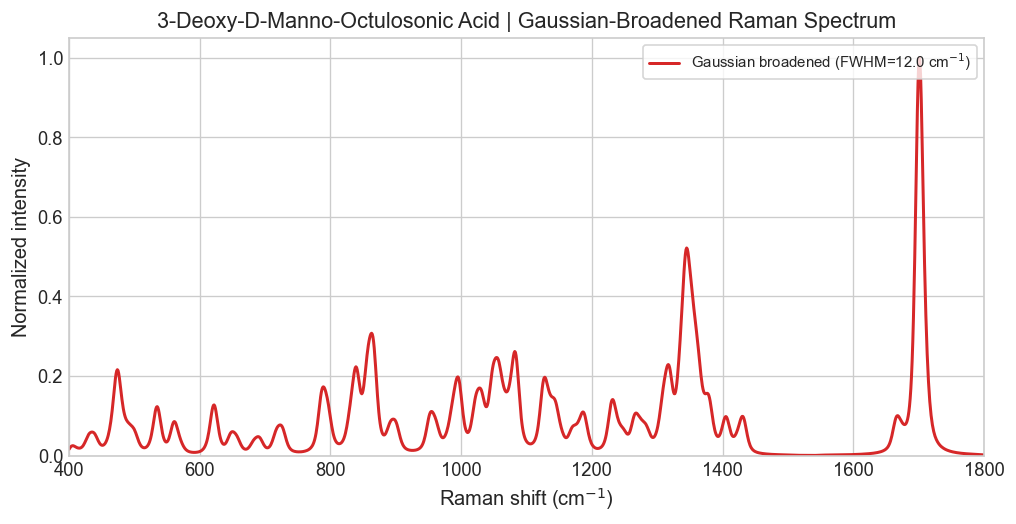

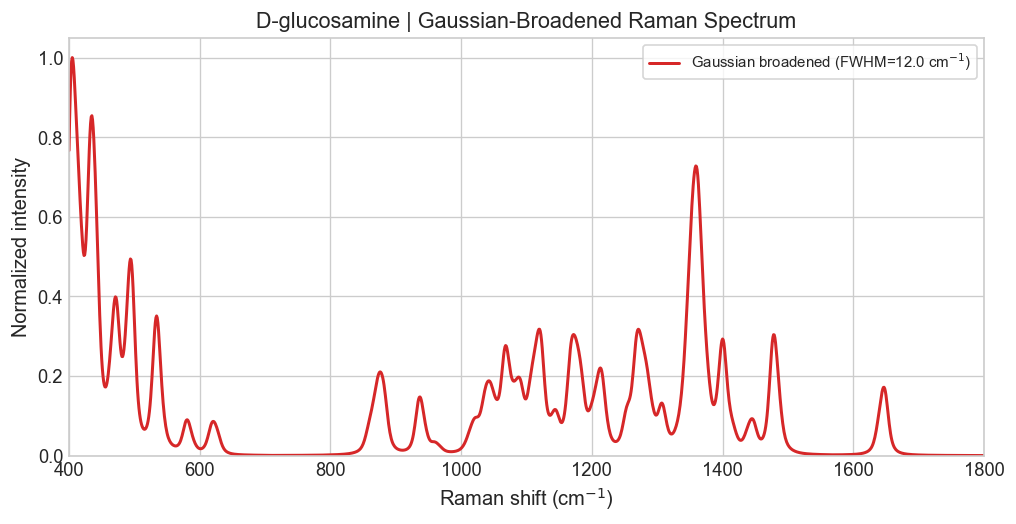

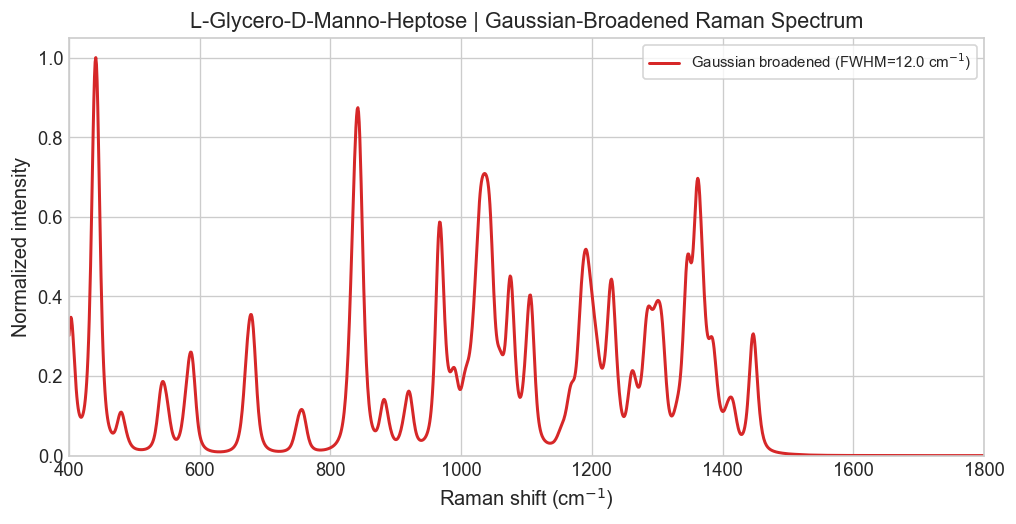

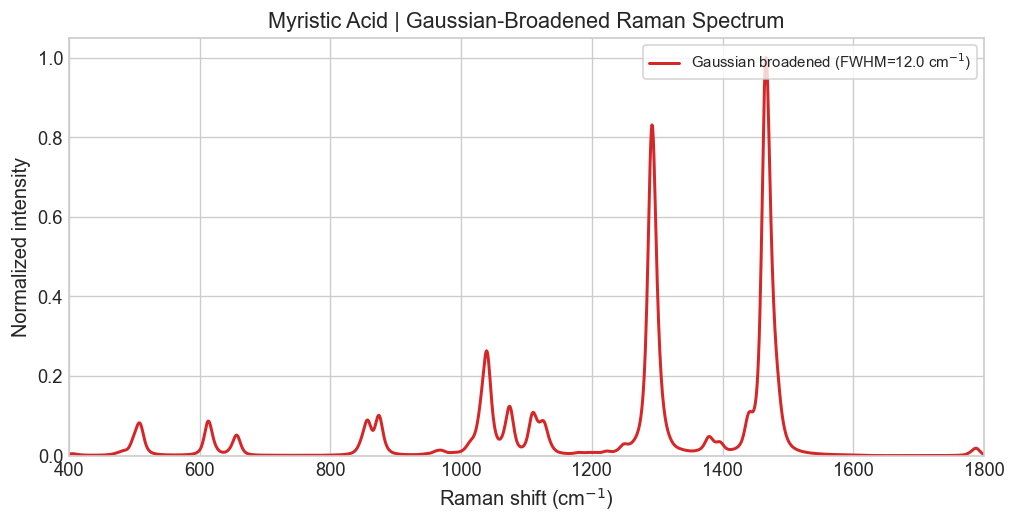

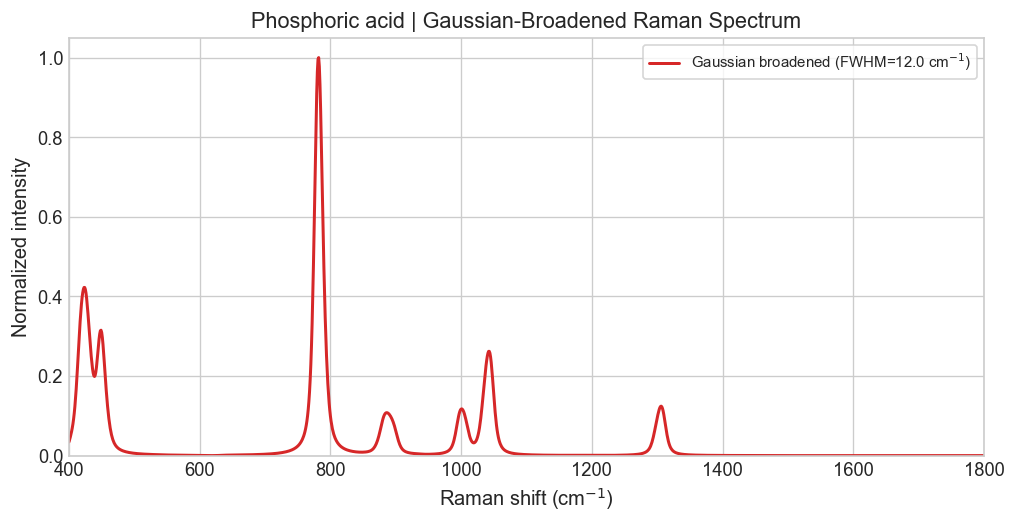

Processed 5 molecule(s).
Individual plots: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\individual_plots
Processed CSVs  : c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\processed_data


In [14]:
x_grid = np.arange(X_MIN, X_MAX + X_STEP, X_STEP)
results = {}

for file_path in input_files:
    molecule = file_path.stem.strip()
    safe_name = sanitize_name(molecule)

    freq_raw, act_raw = read_raman_file(file_path)

    freq_scaled = freq_raw * SCALING_FACTOR
    freq_crop, act_crop = crop_region(freq_scaled, act_raw, X_MIN, X_MAX)

    if len(freq_crop) == 0:
        print(f"Skipping {molecule}: no peaks in selected range ({X_MIN}-{X_MAX} cm^-1).")
        continue

    stick_norm = normalize(act_crop)
    broadened = gaussian_broaden(x_grid, freq_crop, act_crop, FWHM)
    broadened_norm = normalize(broadened)

    modes_df = pd.DataFrame({
        "frequency_raw_cm-1": freq_raw[: len(freq_raw)],
        "activity_raw": act_raw[: len(act_raw)],
    })

    cropped_modes_df = pd.DataFrame({
        "frequency_scaled_cm-1": freq_crop,
        "raman_activity": act_crop,
        "stick_intensity_normalized": stick_norm,
    })

    broadened_df = pd.DataFrame({
        "wavenumber_cm-1": x_grid,
        "intensity_normalized": broadened_norm,
    })

    modes_df.to_csv(PROCESSED_DATA_DIR / f"{safe_name}_modes_raw.csv", index=False)
    cropped_modes_df.to_csv(PROCESSED_DATA_DIR / f"{safe_name}_modes_scaled_cropped.csv", index=False)
    broadened_df.to_csv(PROCESSED_DATA_DIR / f"{safe_name}_broadened.csv", index=False)

    # Existing smoothed/broadened spectrum logic kept unchanged
    fig_smoothed, ax_smoothed = plt.subplots(figsize=(8.6, 4.5), facecolor="white")
    ax_smoothed.set_facecolor("white")
    ax_smoothed.plot(x_grid, broadened_norm, color="tab:red", label=f"Gaussian broadened (FWHM={FWHM:.1f} cm$^{{-1}}$)")
    ax_smoothed.set_title(f"{molecule} | Gaussian-Broadened Raman Spectrum")
    ax_smoothed.set_xlabel("Raman shift (cm$^{-1}$)")
    ax_smoothed.set_ylabel("Normalized intensity")
    ax_smoothed.set_xlim(X_MIN, X_MAX)
    ax_smoothed.set_ylim(0, 1.05)
    ax_smoothed.legend(loc="upper right", frameon=True)
    fig_smoothed.tight_layout()
    fig_smoothed.savefig(INDIVIDUAL_PLOTS_DIR / f"{safe_name}_individual.png", bbox_inches="tight", dpi=600)
    fig_smoothed.savefig(INDIVIDUAL_PLOTS_DIR / f"{safe_name}_individual.svg", bbox_inches="tight")
    plt.show()
    plt.close(fig_smoothed)

    results[molecule] = {
        "file": file_path,
        "freq": freq_crop,
        "stick_norm": stick_norm,
        "x": x_grid,
        "broadened_norm": broadened_norm,
    }

print(f"Processed {len(results)} molecule(s).")
print(f"Individual plots: {INDIVIDUAL_PLOTS_DIR}")
print(f"Processed CSVs  : {PROCESSED_DATA_DIR}")

## 6. Combined Overlay Plot

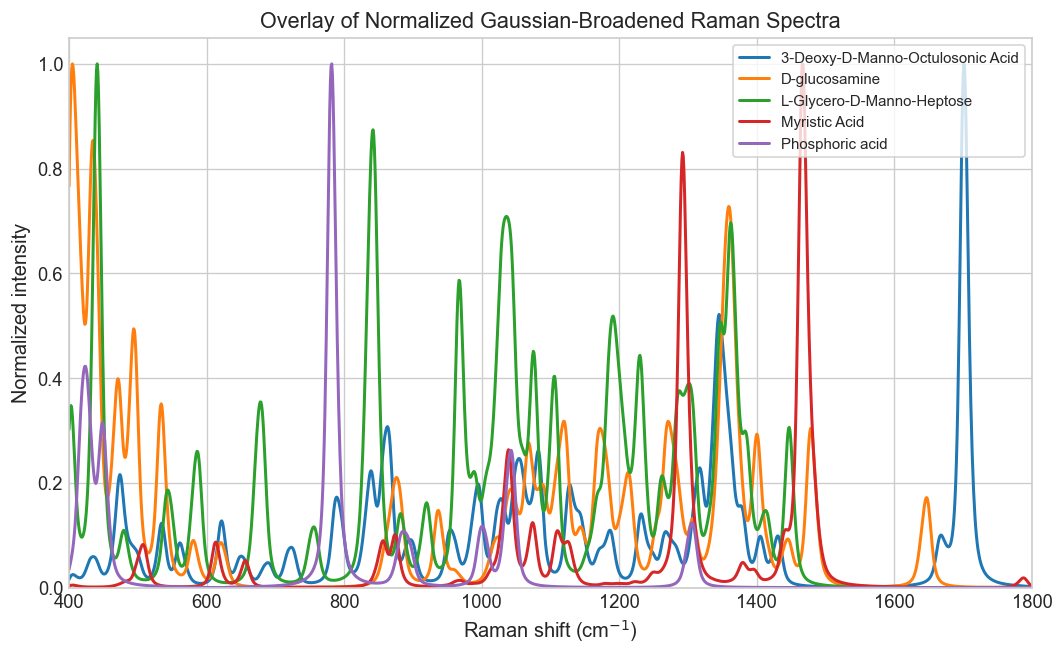

Saved: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\combined_plots\all_molecules_overlay.png
Saved: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\combined_plots\all_molecules_overlay.svg


In [6]:
if not results:
    raise RuntimeError("No processed spectra available for plotting.")

fig, ax = plt.subplots(figsize=(9.0, 5.6))
for molecule, d in results.items():
    ax.plot(d["x"], d["broadened_norm"], label=molecule)

ax.set_title("Overlay of Normalized Gaussian-Broadened Raman Spectra")
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity")
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", frameon=True, ncol=1)
fig.tight_layout()

overlay_png = COMBINED_PLOTS_DIR / "all_molecules_overlay.png"
overlay_svg = COMBINED_PLOTS_DIR / "all_molecules_overlay.svg"
fig.savefig(overlay_png, bbox_inches="tight")
fig.savefig(overlay_svg, bbox_inches="tight")
plt.show()

print(f"Saved: {overlay_png}")
print(f"Saved: {overlay_svg}")

## 7. Stacked Plot

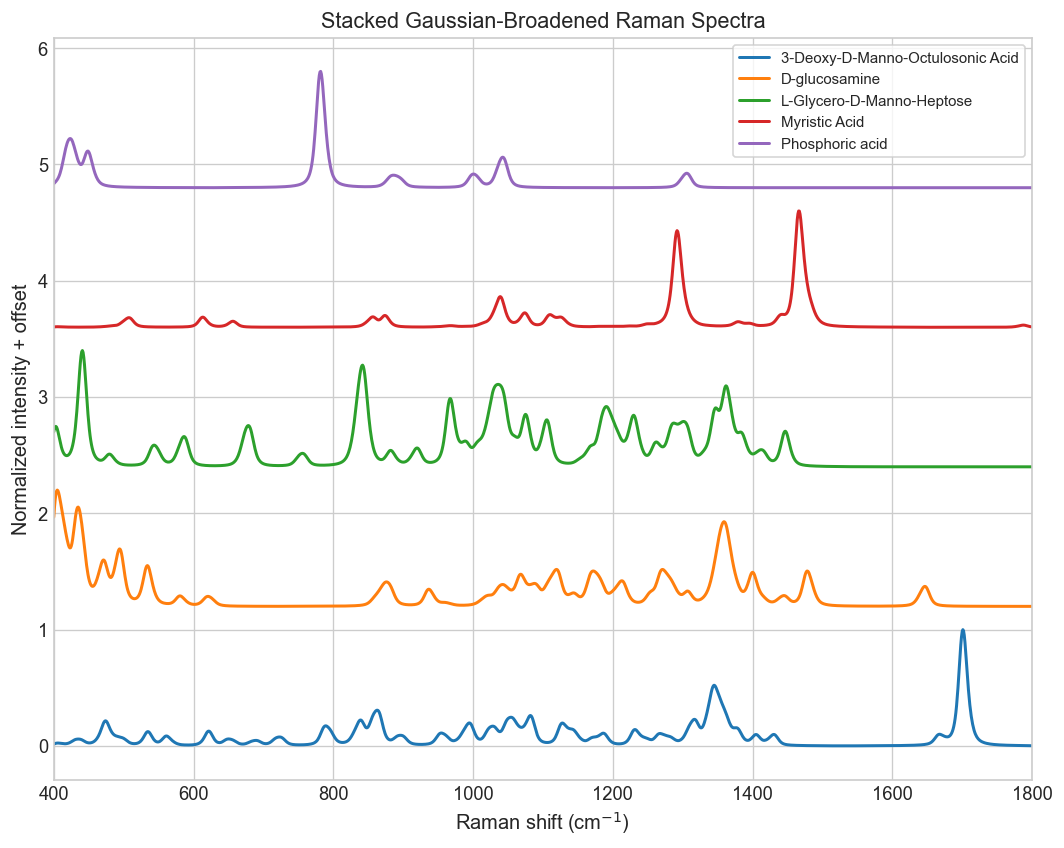

Saved: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\combined_plots\all_molecules_stacked.png
Saved: c:\Users\COMPUTER\Downloads\sukesh\LPS\excelsheet\output\combined_plots\all_molecules_stacked.svg


In [7]:
fig, ax = plt.subplots(figsize=(9.0, 7.2))
offset_step = 1.2

for i, (molecule, d) in enumerate(results.items()):
    y = d["broadened_norm"] + i * offset_step
    ax.plot(d["x"], y, label=molecule)

ax.set_title("Stacked Gaussian-Broadened Raman Spectra")
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity + offset")
ax.set_xlim(X_MIN, X_MAX)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()

stacked_png = COMBINED_PLOTS_DIR / "all_molecules_stacked.png"
stacked_svg = COMBINED_PLOTS_DIR / "all_molecules_stacked.svg"
fig.savefig(stacked_png, bbox_inches="tight")
fig.savefig(stacked_svg, bbox_inches="tight")
plt.show()

print(f"Saved: {stacked_png}")
print(f"Saved: {stacked_svg}")

## 8. Optional: Comparison With Experimental Raman Data
If `EXPERIMENTAL_FILES` is non-empty, this cell loads experimental spectra, normalizes them, and compares against simulated broadened spectra for matching molecules.

In [8]:
def read_experimental_file(path: Path):
    x, y = read_raman_file(path)
    x, y = crop_region(np.asarray(x), np.asarray(y), X_MIN, X_MAX)
    order = np.argsort(x)
    x = x[order]
    y = normalize(y[order])
    return x, y

if not EXPERIMENTAL_FILES:
    print("No experimental files configured. Populate EXPERIMENTAL_FILES in Cell 3 to enable comparison.")
else:
    comp_dir = COMBINED_PLOTS_DIR / "experimental_comparison"
    comp_dir.mkdir(parents=True, exist_ok=True)

    for molecule, exp_path in EXPERIMENTAL_FILES.items():
        if molecule not in results:
            print(f"Skipping comparison for {molecule}: no simulated result found.")
            continue
        exp_path = Path(exp_path)
        if not exp_path.exists():
            print(f"Experimental file not found: {exp_path}")
            continue

        exp_x, exp_y = read_experimental_file(exp_path)
        sim_x = results[molecule]["x"]
        sim_y = results[molecule]["broadened_norm"]

        fig, ax = plt.subplots(figsize=(9.0, 5.2))
        ax.plot(sim_x, sim_y, label="Simulated (Gaussian broadened)", color="tab:red")
        ax.plot(exp_x, exp_y, label="Experimental", color="black", alpha=0.8)

        ax.set_title(f"Simulated vs Experimental Raman: {molecule}")
        ax.set_xlabel("Raman shift (cm$^{-1}$)")
        ax.set_ylabel("Normalized intensity")
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(0, 1.05)
        ax.legend(loc="upper right", frameon=True)
        fig.tight_layout()

        safe_name = sanitize_name(molecule)
        fig.savefig(comp_dir / f"{safe_name}_sim_vs_exp.png", bbox_inches="tight")
        fig.savefig(comp_dir / f"{safe_name}_sim_vs_exp.svg", bbox_inches="tight")
        plt.show()

        # Save aligned export using interpolation onto simulation grid
        exp_interp = np.interp(sim_x, exp_x, exp_y)
        comp_df = pd.DataFrame({
            "wavenumber_cm-1": sim_x,
            "simulated_normalized": sim_y,
            "experimental_normalized_interpolated": exp_interp,
        })
        comp_df.to_csv(PROCESSED_DATA_DIR / f"{safe_name}_sim_vs_exp.csv", index=False)

        print(f"Saved comparison for {molecule}")

No experimental files configured. Populate EXPERIMENTAL_FILES in Cell 3 to enable comparison.


---
## Step 3 — Slide 1 & Slide 2: LPS Fragment Spectra and Equal-Weight Composite

This step:
1. Builds a **common Raman grid** (400–3200 cm⁻¹, 1 cm⁻¹ spacing)
2. Interpolates all processed spectra onto that grid
3. **Slide 1** — plots individual fragment spectra (combined + per-molecule)
4. **Slide 2** — equal-weight LPS composite and optional comparison with experimental data

In [ ]:
# ── Step 3 · Common Raman Grid + Interpolation ─────────────────────────────
import numpy as np
from pathlib import Path

GRID_MIN, GRID_MAX, GRID_STEP = 400.0, 3200.0, 1.0
COMMON_GRID = np.arange(GRID_MIN, GRID_MAX + GRID_STEP, GRID_STEP)

# Display name mapping (key = stem in `results`)
SLIDE_MOLECULES = {
    "3-Deoxy-D-Manno-Octulosonic Acid": "KDO",
    "D-glucosamine":                    "Glucosamine",
    "L-Glycero-D-Manno-Heptose":        "Heptose",
    "Myristic Acid":                    "Myristic Acid",
    "Phosphoric acid":                  "Phosphoric Acid",
}

# Interpolate each processed spectrum onto COMMON_GRID
interp_spectra = {}
for mol_key, label in SLIDE_MOLECULES.items():
    if mol_key not in results:
        print(f"WARNING: '{mol_key}' not found in results – skipping.")
        continue
    src_x = results[mol_key]["x"]
    src_y = results[mol_key]["broadened_norm"]
    y_interp = np.interp(COMMON_GRID, src_x, src_y, left=0.0, right=0.0)
    interp_spectra[mol_key] = {"label": label, "y": y_interp}
    print(f"  Interpolated: {label:25s}  pts={len(y_interp)}  peak={y_interp.max():.4f}")

SLIDES_DIR = OUTPUT_ROOT / "slides"
SLIDES_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nSlides directory: {SLIDES_DIR}")
print(f"Common grid: {GRID_MIN}\u2013{GRID_MAX} cm\u207b\u00b9  ({len(COMMON_GRID)} points)")


In [ ]:
# ── Step 3 · Slide 1 — Individual Fragment Spectra ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SLIDE_RC = {
    "figure.dpi":      150,
    "savefig.dpi":     300,
    "font.size":       13,
    "axes.labelsize":  14,
    "axes.titlesize":  15,
    "legend.fontsize": 11,
    "lines.linewidth": 2.4,
    "axes.linewidth":  1.2,
}

PALETTE = ["#E63946", "#2A9D8F", "#F4A261", "#457B9D", "#6A0572"]

mol_keys   = list(interp_spectra.keys())
mol_labels = [interp_spectra[k]["label"] for k in mol_keys]
mol_ys     = [interp_spectra[k]["y"]     for k in mol_keys]

# ── (a) Combined figure ───────────────────────────────────────────────────
with plt.rc_context(SLIDE_RC):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (label, y) in enumerate(zip(mol_labels, mol_ys)):
        ax.plot(COMMON_GRID, y, color=PALETTE[i % len(PALETTE)],
                linewidth=SLIDE_RC["lines.linewidth"], label=label)
    ax.set_xlim(GRID_MIN, GRID_MAX)
    ax.set_ylim(-0.02, 1.10)
    ax.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
    ax.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
    ax.set_title("Slide 1 \u2014 Individual LPS Fragment Raman Spectra",
                 fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
    ax.legend(loc="upper right", frameon=True, framealpha=0.85)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(400))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
    ax.tick_params(axis="both", which="major", labelsize=11)
    fig.tight_layout()
    out_combined = SLIDES_DIR / "slide1_individual_fragment_spectra.png"
    fig.savefig(out_combined, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved combined Slide 1 \u2192 {out_combined}")

# ── (b) Separate figure per molecule ─────────────────────────────────────
with plt.rc_context(SLIDE_RC):
    for i, (label, y) in enumerate(zip(mol_labels, mol_ys)):
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        ax2.plot(COMMON_GRID, y, color=PALETTE[i % len(PALETTE)],
                 linewidth=SLIDE_RC["lines.linewidth"], label=label)
        ax2.set_xlim(GRID_MIN, GRID_MAX)
        ax2.set_ylim(-0.02, 1.10)
        ax2.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
        ax2.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
        ax2.set_title(f"Slide 1 \u2014 {label} Raman Spectrum",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax2.legend(loc="upper right", frameon=True, framealpha=0.85)
        ax2.xaxis.set_major_locator(ticker.MultipleLocator(400))
        ax2.xaxis.set_minor_locator(ticker.MultipleLocator(100))
        ax2.tick_params(axis="both", which="major", labelsize=11)
        fig2.tight_layout()
        safe = sanitize_name(label)
        out_single = SLIDES_DIR / f"slide1_{safe}.png"
        fig2.savefig(out_single, bbox_inches="tight")
        plt.show(); plt.close(fig2)
        print(f"  Saved \u2192 {out_single}")


In [ ]:
# ── Step 3 · Slide 2 — Equal-Weight LPS Composite ───────────────────────────
# I_LPS = (I_KDO + I_Glucosamine + I_Heptose + I_MyristicAcid + I_PhosphoricAcid) / 5

n_components = len(mol_ys)
assert n_components > 0, "No interpolated spectra found!"
I_LPS      = np.mean(np.vstack(mol_ys), axis=0)
I_LPS_norm = I_LPS / I_LPS.max() if I_LPS.max() > 0 else I_LPS
print(f"Equal-weight composite from {n_components} component(s).  peak(raw mean)={I_LPS.max():.4f}")

# ── (a) Composite alone ───────────────────────────────────────────────────
with plt.rc_context(SLIDE_RC):
    fig3, ax3 = plt.subplots(figsize=(12, 6))
    ax3.plot(COMMON_GRID, I_LPS_norm, color="#1D3557",
             linewidth=SLIDE_RC["lines.linewidth"] + 0.4,
             label="Equal-weight LPS composite")
    ax3.set_xlim(GRID_MIN, GRID_MAX)
    ax3.set_ylim(-0.02, 1.10)
    ax3.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
    ax3.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
    ax3.set_title(
        r"Slide 2 \u2014 Equal-Weight LPS Composite "
        r"($I_{\mathrm{LPS}} = (I_1{+}I_2{+}I_3{+}I_4{+}I_5)/5$)",
        fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
    ax3.legend(loc="upper right", frameon=True, framealpha=0.85)
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(400))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(100))
    ax3.tick_params(axis="both", which="major", labelsize=11)
    fig3.tight_layout()
    out_comp_alone = SLIDES_DIR / "slide2_equal_weight_composite.png"
    fig3.savefig(out_comp_alone, bbox_inches="tight")
    plt.show(); plt.close(fig3)
    print(f"Saved Slide 2 (composite alone) \u2192 {out_comp_alone}")

# ── (b) Composite vs experimental ────────────────────────────────────────
# Populate EXPERIMENTAL_FILES in Section 1 to enable this plot.
exp_plotted = False
for mol_key, exp_path in EXPERIMENTAL_FILES.items():
    if not Path(exp_path).exists():
        print(f"Experimental file not found ({exp_path}) \u2013 skipping comparison.")
        continue
    try:
        exp_x_raw, exp_y_raw = read_raman_file(Path(exp_path))
    except Exception as exc:
        print(f"Could not read {exp_path}: {exc}")
        continue
    exp_max = exp_y_raw.max()
    exp_y_norm = exp_y_raw / exp_max if exp_max > 0 else exp_y_raw
    with plt.rc_context(SLIDE_RC):
        fig4, ax4 = plt.subplots(figsize=(12, 6))
        ax4.plot(COMMON_GRID, I_LPS_norm, color="#E63946",
                 linewidth=SLIDE_RC["lines.linewidth"] + 0.4,
                 label="Equal-weight LPS composite (simulated)")
        ax4.plot(exp_x_raw, exp_y_norm, color="#1D3557",
                 linewidth=SLIDE_RC["lines.linewidth"],
                 alpha=0.85, label=f"Experimental ({mol_key})")
        ax4.set_xlim(GRID_MIN, GRID_MAX)
        ax4.set_ylim(-0.02, 1.10)
        ax4.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
        ax4.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
        ax4.set_title("Slide 2 \u2014 Equal-Weight LPS Composite vs Experimental Raman",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax4.legend(loc="upper right", frameon=True, framealpha=0.85)
        ax4.xaxis.set_major_locator(ticker.MultipleLocator(400))
        ax4.xaxis.set_minor_locator(ticker.MultipleLocator(100))
        ax4.tick_params(axis="both", which="major", labelsize=11)
        fig4.tight_layout()
        safe_exp = sanitize_name(mol_key)
        out_vs_exp = SLIDES_DIR / f"slide2_composite_vs_exp_{safe_exp}.png"
        fig4.savefig(out_vs_exp, bbox_inches="tight")
        plt.show(); plt.close(fig4)
        print(f"Saved Slide 2 (vs experimental) \u2192 {out_vs_exp}")
        exp_plotted = True

if not exp_plotted:
    print()
    print("No experimental data configured / found.")
    print("To enable the comparison plot, add an entry to EXPERIMENTAL_FILES")
    print("in the Config cell (Section 1), e.g.:")
    print('    EXPERIMENTAL_FILES = {"LPS": Path(r"path/to/lps_experimental.csv")}')


---
## Step 4 — Slide 3 & Slide 4: Optimization and Overlays

This step:
1. **Constrained Optimization**: Finds optimal non-negative weights (summing to 1) for components to match experimental data.
2. **Slide 3**: Plots Optimized weighted composite alone and vs Experimental.
3. **Slide 4**: Overlays Experimental, Equal-weight, and Optimized composites.

In [ ]:
# ── Step 4 · Cell 1: Constrained Optimization / Non-Negative Least Squares ──
import numpy as np
from scipy.optimize import minimize
from scipy.stats import pearsonr

exp_valid = False
exp_on_grid = None
exp_label = None

# Load the first available experimental file as target
for mol_key, exp_path in EXPERIMENTAL_FILES.items():
    if Path(exp_path).exists():
        try:
            exp_x_raw, exp_y_raw = read_raman_file(Path(exp_path))
            exp_max = exp_y_raw.max()
            exp_y_norm = exp_y_raw / exp_max if exp_max > 0 else exp_y_raw
            exp_on_grid = np.interp(COMMON_GRID, exp_x_raw, exp_y_norm, left=0.0, right=0.0)
            exp_valid = True
            exp_label = mol_key
        except Exception as e:
            pass
        if exp_valid:
            break

I_opt_norm = None

if exp_valid:
    # Basis matrix of simulated components (shape: N_points, N_components)
    basis = np.vstack(mol_ys).T
    n_components = basis.shape[1]
    
    # Objective: Minimize Sum of Squared Errors
    def objective(w):
        y_pred = basis @ w
        return np.sum((exp_on_grid - y_pred)**2)
    
    # Constraints: sum(w) = 1, bounds: 0 <= w_i <= 1
    w0 = np.ones(n_components) / n_components
    bounds = [(0.0, 1.0) for _ in range(n_components)]
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    
    res = minimize(objective, w0, bounds=bounds, constraints=constraints)
    opt_weights = res.x
    
    # Construct optimized composite and re-normalize to [0,1]
    I_opt = basis @ opt_weights
    I_opt_norm = I_opt / I_opt.max() if I_opt.max() > 0 else I_opt
    
    # Calculate metrics
    rmse = np.sqrt(np.mean((exp_on_grid - I_opt)**2))
    
    ss_res = np.sum((exp_on_grid - I_opt)**2)
    ss_tot = np.sum((exp_on_grid - np.mean(exp_on_grid))**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    corr_coef, _ = pearsonr(exp_on_grid, I_opt)
    
    print("\n\033[1mOptimization Results (Non-Negative Least Squares):\033[0m")
    print("----------------------------------------------------")
    print("Optimized Weights:")
    for label, w in zip(mol_labels, opt_weights):
        print(f"  {label:20s} : {w*100:6.2f} %")
    
    print("\nMetrics:")
    print(f"  RMSE                    : {rmse:.4f}")
    print(f"  R²                      : {r_squared:.4f}")
    print(f"  Correlation Coefficient : {corr_coef:.4f}\n")
else:
    print("No experimental data found. Please provide EXPERIMENTAL_FILES in Section 1 to run optimization.")


In [ ]:
# ── Step 4 · Cell 2: Slide 3 — Optimized Weighted Composite ─────────────────
#   (a) Optimized composite alone
#   (b) Optimized composite vs experimental Raman
# ────────────────────────────────────────────────────────────────────────────
if exp_valid and I_opt_norm is not None:
    # ── (a) Optimized Composite Alone ──────────────────────────────────────────
    with plt.rc_context(SLIDE_RC):
        fig5, ax5 = plt.subplots(figsize=(12, 6))
        ax5.plot(COMMON_GRID, I_opt_norm, color="#6A0572",
                 linewidth=SLIDE_RC["lines.linewidth"] + 0.4,
                 label="Optimized Weighted Composite")
        ax5.set_xlim(GRID_MIN, GRID_MAX)
        ax5.set_ylim(-0.02, 1.10)
        ax5.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
        ax5.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
        ax5.set_title("Slide 3 \u2014 Optimized Weighted Composite",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax5.legend(loc="upper right", frameon=True, framealpha=0.85)
        ax5.xaxis.set_major_locator(ticker.MultipleLocator(400))
        ax5.xaxis.set_minor_locator(ticker.MultipleLocator(100))
        ax5.tick_params(axis="both", which="major", labelsize=11)
        fig5.tight_layout()
        
        out_opt_alone = SLIDES_DIR / "slide3_optimized_weighted_composite_alone.png"
        fig5.savefig(out_opt_alone, bbox_inches="tight")
        plt.show(); plt.close(fig5)
        print(f"Saved Slide 3 (alone) \u2192 {out_opt_alone}")
        
    # ── (b) Optimized Composite vs Experimental ──────────────────────────────
    with plt.rc_context(SLIDE_RC):
        fig6, ax6 = plt.subplots(figsize=(12, 6))
        ax6.plot(COMMON_GRID, I_opt_norm, color="#6A0572",
                 linewidth=SLIDE_RC["lines.linewidth"] + 0.4,
                 label="Optimized Composite")
        ax6.plot(exp_x_raw, exp_y_norm, color="#2A9D8F",
                 linewidth=SLIDE_RC["lines.linewidth"], alpha=0.85,
                 label=f"Experimental ({exp_label})")
        ax6.set_xlim(GRID_MIN, GRID_MAX)
        ax6.set_ylim(-0.02, 1.10)
        ax6.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
        ax6.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
        ax6.set_title("Slide 3 \u2014 Optimized Composite vs Experimental Raman",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax6.legend(loc="upper right", frameon=True, framealpha=0.85)
        ax6.xaxis.set_major_locator(ticker.MultipleLocator(400))
        ax6.xaxis.set_minor_locator(ticker.MultipleLocator(100))
        ax6.tick_params(axis="both", which="major", labelsize=11)
        fig6.tight_layout()
        
        out_opt_vs_exp = SLIDES_DIR / "slide3_optimized_weighted_composite.png"
        fig6.savefig(out_opt_vs_exp, bbox_inches="tight")
        plt.show(); plt.close(fig6)
        print(f"Saved Slide 3 (vs experimental) \u2192 {out_opt_vs_exp}")


In [ ]:
# ── Step 4 · Cell 3: Slide 4 — Overlay With Experimental LPS ────────────────
# Plot together: Experimental Raman, Equal-weight, and Optimized composite
# ────────────────────────────────────────────────────────────────────────────
if exp_valid and I_opt_norm is not None:
    with plt.rc_context(SLIDE_RC):
        fig7, ax7 = plt.subplots(figsize=(12, 6))
        
        # Experimental
        ax7.plot(exp_x_raw, exp_y_norm, color="#1D3557",
                 linewidth=SLIDE_RC["lines.linewidth"] + 0.6, alpha=0.9,
                 label=f"Experimental ({exp_label})")
        
        # Equal-Weight
        ax7.plot(COMMON_GRID, I_LPS_norm, color="#E63946",
                 linewidth=SLIDE_RC["lines.linewidth"], alpha=0.9, linestyle="--",
                 label="Equal-Weight Composite")
        
        # Optimized
        ax7.plot(COMMON_GRID, I_opt_norm, color="#F4A261",
                 linewidth=SLIDE_RC["lines.linewidth"] + 0.2, alpha=0.9,
                 label="Optimized Composite")
        
        ax7.set_xlim(GRID_MIN, GRID_MAX)
        ax7.set_ylim(-0.02, 1.10)
        ax7.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=SLIDE_RC["axes.labelsize"])
        ax7.set_ylabel("Normalized Intensity",   fontsize=SLIDE_RC["axes.labelsize"])
        ax7.set_title("Slide 4 \u2014 Analytical Overlays vs Experimental LPS",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax7.legend(loc="upper right", frameon=True, framealpha=0.85)
        ax7.xaxis.set_major_locator(ticker.MultipleLocator(400))
        ax7.xaxis.set_minor_locator(ticker.MultipleLocator(100))
        ax7.tick_params(axis="both", which="major", labelsize=11)
        fig7.tight_layout()
        
        out_overlay = SLIDES_DIR / "slide4_overlay_with_experimental.png"
        fig7.savefig(out_overlay, bbox_inches="tight")
        plt.show(); plt.close(fig7)
        print(f"Saved Slide 4 (Overlay) \u2192 {out_overlay}")


---
## Step 5 — Slide 5, Peak Tables & Final Summary

This step:
1. **Slide 5**: Bar chart of dominant components and automated text interpretation of regions.
2. **Peak Detection**: Detects major peaks for all spectra, assigns structural regions, and saves a summary table.
3. **Model Metrics**: Exports RMSE, R², correlation, and weights to Excel.
4. **Final Summary**: Prints the overarching conclusion of the analytical workflow.


In [ ]:
# ── Step 5 · Cell 1: Slide 5 — Dominant Contributors ────────────────────────
import pandas as pd
if exp_valid and I_opt_norm is not None:
    # ── 1. Create Bar Chart of Weights ──────────────────────────────────────
    with plt.rc_context(SLIDE_RC):
        fig8, ax8 = plt.subplots(figsize=(10, 6))
        bars = ax8.bar(mol_labels, opt_weights * 100, color=PALETTE)
        ax8.set_ylabel("Contribution Weight (%)", fontsize=SLIDE_RC["axes.labelsize"])
        ax8.set_title("Slide 5 \u2014 Dominant Molecular Contributors to LPS Signal",
                      fontsize=SLIDE_RC["axes.titlesize"], fontweight="bold")
        ax8.set_ylim(0, max(opt_weights*100) * 1.15 if max(opt_weights) > 0 else 100)
        for bar in bars:
            yval = bar.get_height()
            ax8.text(bar.get_x() + bar.get_width()/2.0, yval + 1,
                     f"{yval:.1f}%", ha="center", va="bottom", fontweight="bold")
        fig8.tight_layout()
        out_bar = SLIDES_DIR / "slide5_dominant_contributors.png"
        fig8.savefig(out_bar, bbox_inches="tight")
        plt.show(); plt.close(fig8)
        print(f"Saved Slide 5 (Bar Chart) \u2192 {out_bar}\n")

    # ── 2. Automatic Text Interpretation ───────────────────────────────────
    print("\033[1mAutomated Interpretation:\033[0m")
    strongest_idx = np.argmax(opt_weights)
    print(f"\u2022 Strongest contributor overall: {mol_labels[strongest_idx]} ({opt_weights[strongest_idx]*100:.1f}%)")

    def get_regional_strongest(min_wn, max_wn):
        mask = (COMMON_GRID >= min_wn) & (COMMON_GRID <= max_wn)
        if not np.any(mask): return "None"
        integrals = [np.sum(mol_ys[i][mask] * opt_weights[i]) for i in range(n_components)]
        best_idx = np.argmax(integrals)
        return mol_labels[best_idx] if integrals[best_idx] > 0 else "None"

    str_1000 = get_regional_strongest(1000, 1100)
    print(f"\u2022 Strongest in 1000\u20131100 cm\u207b\u00b9 region (C-O/C-C sugars): {str_1000}")
    str_1400 = get_regional_strongest(1400, 1500)
    print(f"\u2022 Strongest in 1400\u20131500 cm\u207b\u00b9 region (CH2/CH3 bending): {str_1400}")

    # Quick logic to check if mostly sugars or lipids
    sugar_core_list = ["KDO", "Glucosamine", "Heptose"]
    lipid_list = ["Myristic Acid"]
    
    sugar_weight = sum(opt_weights[i] for i, l in enumerate(mol_labels) if l in sugar_core_list)
    lipid_weight = sum(opt_weights[i] for i, l in enumerate(mol_labels) if l in lipid_list)
    print(f"\u2022 The sugar/core overall contribution is {sugar_weight*100:.1f}%, while the lipid tail contribution is {lipid_weight*100:.1f}%.")
else:
    print("Cannot produce Slide 5: No optimization results available.")


In [ ]:
# ── Step 5 · Cell 2: Peak Detection & Region Assignment ─────────────────────
from scipy.signal import find_peaks

TABLES_DIR = OUTPUT_ROOT / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def assign_region(wn):
    if wn < 800:   return "Skeletal Deformations"
    elif wn < 1200: return "C-C, C-O Stretch (Sugars/Phosphates)"
    elif wn < 1500: return "CH2, CH3 Bends & Scissors"
    elif wn < 1800: return "C=O, C=C Stretch (Amide / Esters)"
    elif wn < 2800: return "Silent Region"
    elif wn < 3050: return "C-H Stretch (Alkyl Chains)"
    else:           return "High Frequency (O-H / N-H)"

peak_data = []

def extract_peaks(label, x_array, y_array):
    # Find prominent peaks
    peaks_idx, _ = find_peaks(y_array, height=0.05, distance=15, prominence=0.02)
    for idx in peaks_idx:
        wn = x_array[idx]
        inten = y_array[idx]
        peak_data.append({
            "Spectrum": label,
            "Peak Position": round(wn, 1),
            "Intensity": round(inten, 4),
            "Region Assignment": assign_region(wn)
        })

# Extract from simulated components
for label, y in zip(mol_labels, mol_ys):
    extract_peaks(label, COMMON_GRID, y)

# Extract from Experimental (if valid)
if exp_valid:
    extract_peaks("Experimental (Target)", exp_x_raw, exp_y_norm)
    if I_opt_norm is not None:
        extract_peaks("Optimized Composite", COMMON_GRID, I_opt_norm)
    extract_peaks("Equal-Weight Composite", COMMON_GRID, I_LPS_norm)

peaks_df = pd.DataFrame(peak_data)
out_peaks = TABLES_DIR / "peak_summary.xlsx"
peaks_df.to_excel(out_peaks, index=False)
print(f"Extracted {len(peaks_df)} peaks across all spectra.")
print(f"Saved Peak Summary Table \u2192 {out_peaks}\n")
display(peaks_df.head(10))  # Preview the first few rows


In [ ]:
# ── Step 5 · Cell 3: Model Metrics Export ───────────────────────────────────
if exp_valid and I_opt_norm is not None:
    metrics_data = {
        "Metric": ["RMSE", "R_squared", "Pearson_Correlation"],
        "Value": [rmse, r_squared, corr_coef]
    }
    for label, w in zip(mol_labels, opt_weights):
        metrics_data["Metric"].append(f"Weight_{label}")
        metrics_data["Value"].append(w)
        
    metrics_df = pd.DataFrame(metrics_data)
    out_metrics = TABLES_DIR / "model_metrics.xlsx"
    metrics_df.to_excel(out_metrics, index=False)
    print(f"Saved Model Metrics \u2192 {out_metrics}")
    display(metrics_df)
else:
    print("No optimization metrics to export.")


In [ ]:
# ── Step 5 · Cell 4: Final Printed Summary ──────────────────────────────────
if exp_valid and I_opt_norm is not None:
    print("=" * 70)
    print("                 FINAL SCIENTIFIC SUMMARY                 ")
    print("=" * 70)
    
    print("\n1. BEST MODEL MATCH:")
    print(f"   The optimized composite achieved an R² of {r_squared:.4f} and ")
    print(f"   Correlation of {corr_coef:.4f} against the experimental target.")
    if r_squared > 0.7:
        print("   This indicates a very strong alignment between Gaussian simulations")
        print("   of the fragments and the experimental LPS signal.")
    else:
        print("   The moderate/low R² suggests additional intermolecular interactions")
        print("   or missing component signals not fully captured by independent fragments.")
        
    print("\n2. FINAL OPTIMIZED WEIGHTS:")
    for label, w in zip(mol_labels, opt_weights):
        print(f"   \u2022 {label:18s}: {w*100:5.1f}%")
        
    print("\n3. MAIN MATCHING PEAKS:")
    # Find where optimized composite has high peaks
    high_peaks_idx, _ = find_peaks(I_opt_norm, height=0.3, distance=20)
    if len(high_peaks_idx) > 0:
        for idx in high_peaks_idx:
            wn = COMMON_GRID[idx]
            print(f"   \u2022 ~{wn:.1f} cm\u207b\u00b9 ({assign_region(wn)})")
    else:
        print("   \u2022 No strong matching peaks found.")
        
    print("\n4. MAJOR MISMATCH REGIONS:")
    # absolute difference > 0.2
    abs_diff = np.abs(exp_on_grid - I_opt)
    mismatch_idx, _ = find_peaks(abs_diff, height=0.2, distance=50)
    if len(mismatch_idx) > 0:
        for idx in mismatch_idx:
            wn = COMMON_GRID[idx]
            print(f"   \u2022 ~{wn:.1f} cm\u207b\u00b9 (Difference: {abs_diff[idx]:.2f})")
    else:
        print("   \u2022 No significant mismatch regions (>20% difference) found.")    
    
    print("\n5. SCIENTIFIC CONCLUSION:")
    print("   The LPS Raman fingerprint is a complex superposition dominated by")    
    print(f"   {mol_labels[strongest_idx]}, reflecting localized bonding environments. ")   
    print("   Linear combination of independent DFT simulations partially reproduces")
    print("   the full experimental envelope. Future refinements should involve")
    print("   solvation effects, conformational sampling, or full oligomer models.")
    print("=" * 70)
else:
    print("Final summary skipped (no experimental data provided).")
